In [18]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorSampler as Sampler
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, balanced_accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Using FakeMarrakesh to simulate IBM quantum hardware locally — free and unlimited
backend = FakeMarrakesh()

In [20]:
df = pd.read_csv('../data/cleaned/wildfire_cleaned.csv')

In [21]:
df.head()

,zip,year,fire_occurred,avg_tmax_c,avg_tmin_c,tot_prcp_mm,prev_year_fire,prev_year_acres,rolling_3yr_fire_count
0,85364,2020,1,23.938875,10.715056,241.85,0,0.0,0.0
1,89029,2020,1,23.938875,10.715056,241.85,0,0.0,0.0
2,89029,2022,0,23.938875,10.715056,241.85,0,0.0,1.0
3,89439,2019,1,23.938875,10.715056,241.85,0,0.0,0.0
4,89439,2023,0,23.938875,10.715056,241.85,0,0.0,0.0


In [22]:
test_2023 = df[df["year"] == 2023] # Saving 2023 data to be compared later
df = df[df["year"].between(2018, 2022)].reset_index(drop=True)

assert "fire_occurred" in df.columns, "Missing target column!"
assert df["fire_occurred"].isin([0, 1]).all(), "Target column has non-binary values!"
assert df.duplicated(subset=["year", "zip"]).sum() == 0, "Duplicate Year+ZIP rows found!"
assert df["avg_tmax_c"].isnull().sum() == 0, "Null values found in weather features!"

print("Shape:", df.shape)
print("Years:", sorted(df["year"].unique()))
print("Unique ZIPs:", df["zip"].nunique())
print("Nulls:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nTarget distribution:")
print(df["fire_occurred"].value_counts())
print(f"Class imbalance ratio: {df['fire_occurred'].value_counts()[0] / df['fire_occurred'].value_counts()[1]:.1f}:1")

Shape: (3650, 9)
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Unique ZIPs: 2009
Nulls:
 Series([], dtype: int64)

Target distribution:
fire_occurred
0    2599
1    1051
Name: count, dtype: int64
Class imbalance ratio: 2.5:1


In [23]:
df["temp_range"] = df["avg_tmax_c"] - df["avg_tmin_c"]  # daily temperature swing
test_2023["temp_range"] = test_2023["avg_tmax_c"] - test_2023["avg_tmin_c"]

print("Final features:")
print(df.drop(columns=["fire_occurred"]).columns.tolist())
print("\nShape:", df.shape)

Final features:
['zip', 'year', 'avg_tmax_c', 'avg_tmin_c', 'tot_prcp_mm', 'prev_year_fire', 'prev_year_acres', 'rolling_3yr_fire_count', 'temp_range']

Shape: (3650, 10)


In [24]:
# Split by year — train on past, test on future (mirrors real prediction task)
# avoids data leakage from random splitting across years
train = df[df["year"] <= 2021]
test  = df[df["year"] == 2022]

X_train = train.drop(columns=["fire_occurred"])
y_train = train["fire_occurred"]

X_test = test.drop(columns=["fire_occurred"])
y_test = test["fire_occurred"]

print("Train:", X_train.shape, y_train.value_counts().to_dict())
print("Test:", X_test.shape, y_test.value_counts().to_dict())

Train: (2931, 9) {0: 2052, 1: 879}
Test: (719, 9) {0: 547, 1: 172}


In [25]:
FEATURES = [c for c in df.columns if c not in ["zip", "year", "fire_occurred"]]
X_train, y_train = train[FEATURES].values, train["fire_occurred"].values
X_test,  y_test  = test[FEATURES].values,  test["fire_occurred"].values

print("\nTrain shape:", X_train.shape)
print("Test shape: ", X_test.shape)


Train shape: (2931, 7)
Test shape:  (719, 7)


In [26]:
# RandomForest to rank feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nFeature importances:\n", importances)

TOP_N = 6  # capped at 6 — new dataset has 7 features total
top_features = importances.head(TOP_N).index.tolist()
print(f"\nTop {TOP_N} features selected:", top_features)
X_train = train[top_features].values
X_test  = test[top_features].values

# Normalize to [-π, π] for quantum encoding
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nFeature range after scaling:")
print("  Min:", X_train.min().round(3), " Max:", X_train.max().round(3))


Feature importances:
 avg_tmin_c                0.240685
avg_tmax_c                0.203989
temp_range                0.197175
tot_prcp_mm               0.150844
rolling_3yr_fire_count    0.122800
prev_year_acres           0.049666
prev_year_fire            0.034842
dtype: float64

Top 6 features selected: ['avg_tmin_c', 'avg_tmax_c', 'temp_range', 'tot_prcp_mm', 'rolling_3yr_fire_count', 'prev_year_acres']

Feature range after scaling:
  Min: -3.142  Max: 3.142


In [27]:
# This is the actual quantum portion of our code. we're using a ZZFeatureMap, which basically encodes our feature columns into
# their quantum states (converting their values into quantum bits).

NUM_QUBITS = 6  # matches TOP_N above

feature_map = zz_feature_map(
    feature_dimension = 6,
    reps = 2, 
    entanglement = "linear"
)

print(f"Number of qubits : {feature_map.num_qubits}")
print(f"Circuit depth    : {feature_map.decompose().depth()}")
print(f"Number of params : {feature_map.num_parameters}")
print()
feature_map.decompose().draw("text")

# Ok this circuit looks very confusing, but it's just showing the encoding process of our features.

Number of qubits : 6
Circuit depth    : 25
Number of params : 6



┌────────────┐┌───────────────┐                                         »
0: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[0]) ├──■──────────────────────────────────────»
   ├────────────┤├───────────────┤┌─┴─┐┌──────────────────────────────────┐»
1: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[1]) ├┤ X ├┤ U(0,0,(-π + x[0])*(-π + x[1])*2) ├»
   ├────────────┤├───────────────┤└───┘└──────────────────────────────────┘»
2: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[2]) ├─────────────────────────────────────────»
   ├────────────┤├───────────────┤                                         »
3: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[3]) ├─────────────────────────────────────────»
   ├────────────┤├───────────────┤                                         »
4: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[4]) ├─────────────────────────────────────────»
   ├────────────┤├───────────────┤                                         »
5: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[5]) ├─────────────────────────────────────────»
   └────────────┘└───────────────┘                                         »
«        ┌────────────┐         ┌───────────────┐                             »
«0: ──■──┤ U(π/2,0,π) ├─────────┤ U(0,0,2*x[0]) ├─────────────────────────────»
«   ┌─┴─┐└────────────┘         └───────────────┘               ┌────────────┐»
«1: ┤ X ├──────■─────────────────────────────────────────────■──┤ U(π/2,0,π) ├»
«   └───┘    ┌─┴─┐     ┌──────────────────────────────────┐┌─┴─┐└────────────┘»
«2: ─────────┤ X ├─────┤ U(0,0,(-π + x[1])*(-π + x[2])*2) ├┤ X ├──────■───────»
«            └───┘     └──────────────────────────────────┘└───┘    ┌─┴─┐     »
«3: ────────────────────────────────────────────────────────────────┤ X ├─────»
«                                                                   └───┘     »
«4: ──────────────────────────────────────────────────────────────────────────»
«                                                                             »
«5: ──────────────────────────────────────────────────────────────────────────»
«                                                                             »
«                                            »
«0: ──────────────────────────────────────■──»
«            ┌───────────────┐          ┌─┴─┐»
«1: ─────────┤ U(0,0,2*x[1]) ├──────────┤ X ├»
«            └───────────────┘          └───┘»
«2: ──────────────────────────────────────■──»
«   ┌──────────────────────────────────┐┌─┴─┐»
«3: ┤ U(0,0,(-π + x[2])*(-π + x[3])*2) ├┤ X ├»
«   └──────────────────────────────────┘└───┘»
«4: ─────────────────────────────────────────»
«                                            »
«5: ─────────────────────────────────────────»
«                                            »
«                                                                           »
«0: ─────────────────────────────────────────────────────■──────────────────»
«   ┌──────────────────────────────────┐               ┌─┴─┐                »
«1: ┤ U(0,0,(-π + x[0])*(-π + x[1])*2) ├───────────────┤ X ├────────────────»
«   └──────────┬────────────┬──────────┘         ┌─────┴───┴─────┐          »
«2: ───────────┤ U(π/2,0,π) ├────────────────────┤ U(0,0,2*x[2]) ├──────────»
«              └────────────┘                    └───────────────┘          »
«3: ─────────────────■──────────────────────────────────────────────────────»
«                  ┌─┴─┐                ┌──────────────────────────────────┐»
«4: ───────────────┤ X ├────────────────┤ U(0,0,(-π + x[3])*(-π + x[4])*2) ├»
«                  └───┘                └──────────────────────────────────┘»
«5: ────────────────────────────────────────────────────────────────────────»
«                                                                           »
«                                            »
«0: ─────────────────────────────────────────»
«                                            »
«1: ──■──────────────────────────────────────»
«   ┌─┴─┐┌──────────────────────────────────┐»
«2: ┤ X ├┤ U(0,0,(-π + x[1])*(-π + x[2])*2) ├»
«   └───┘└──────────┬────────────┬──────────┘»
«3: ──■─

In [28]:
# A sampler is just the backend that actually runs the quantum circuit. it's just like how we have to select a kernel
# to run Python.
sampler  = Sampler()
fidelity = ComputeUncompute(sampler=sampler)

quantum_kernel = FidelityQuantumKernel(
    feature_map = feature_map,
    fidelity = fidelity
)

# SVC stands for Support Vector Classifier. It's a classic ML model which essentially looks at our data and finds the best boundary line
# or (divider) that separates the two classes that we're checking for (in our case, wildfire or no wildfire)
model = SVC(
    kernel = 'rbf',
    probability = False,  # By making this true, we make the model output a probability score instead of just yes/no
    class_weight = 'balanced',
    random_state = 42
)

quantum_model = SVC(
    kernel = quantum_kernel.evaluate,
    probability = True,   # By making this true, we make the model output a probability score instead of just yes/no
    class_weight = 'balanced',
    random_state = 42
)

In [12]:
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [13]:
conf_matrix = confusion_matrix(y_test, pred)
class_report = classification_report(y_test, pred, zero_division = 0)
balanced_accuracy = balanced_accuracy_score(y_test, pred)
fl_weighted = f1_score(y_test, pred, average = 'weighted')
f1_macro = f1_score(y_test, pred, average = 'macro')

print(class_report)
print(f'Balanced Accuracy: {balanced_accuracy}')
print(f'F1-Weighted: {fl_weighted}')
print(f'F1-Macro: {f1_macro}')
print(conf_matrix)

              precision    recall  f1-score   support

           0       0.81      0.70      0.75        50
           1       0.74      0.84      0.79        50

    accuracy                           0.77       100
   macro avg       0.78      0.77      0.77       100
weighted avg       0.78      0.77      0.77       100

Balanced Accuracy: 0.77
F1-Weighted: 0.7688674505074866
F1-Macro: 0.7688674505074866
[[35 15]
 [ 8 42]]


In [14]:
quantum_model.fit(X_train, y_train)
quantum_pred = quantum_model.predict(X_test)
quantum_prob = quantum_model.predict_proba(X_test)[:, 1]

In [15]:
conf_matrix = confusion_matrix(y_test, quantum_pred)
class_report = classification_report(y_test, quantum_pred, zero_division = 0)
balanced_accuracy = balanced_accuracy_score(y_test, quantum_pred)
fl_weighted = f1_score(y_test, quantum_pred, average = 'weighted')
f1_macro = f1_score(y_test, quantum_pred, average = 'macro')
roc_auc = roc_auc_score(y_test, quantum_prob)

print(class_report)
print(f"ROC-AUC: {roc_auc}")
print(f'Balanced Accuracy: {balanced_accuracy}')
print(f'F1-Weighted: {fl_weighted}')
print(f'F1-Macro: {f1_macro}')

print(conf_matrix)

              precision    recall  f1-score   support

           0       0.76      0.58      0.66        50
           1       0.66      0.82      0.73        50

    accuracy                           0.70       100
   macro avg       0.71      0.70      0.70       100
weighted avg       0.71      0.70      0.70       100

ROC-AUC: 0.81
Balanced Accuracy: 0.7
F1-Weighted: 0.695616883116883
F1-Macro: 0.6956168831168831
[[29 21]
 [ 9 41]]


Since I know that the QML does work (it just takes a lot of time), I can confidently move on and just train the full dataset when I complete my notebook. - Calvin

In [ ]:
# Prepare 2023 feature data
X_2023 = test_2023[top_features].values
X_2023 = scaler.transform(X_2023)

# Generate risk scores
risk_scores = quantum_model.predict_proba(X_2023)[:, 1]
risk_labels = quantum_model.predict(X_2023)

# Build results dataframe
results_2023 = pd.DataFrame({
    "zip": test_2023["zip"].values,
    "risk_score": risk_scores,
    "wildfire_predicted": risk_labels
})

results_2023 = results_2023.sort_values("risk_score", ascending=False).reset_index(drop=True)

print("2023 Predictions:")
print(f"ZIPs predicted as high risk: {risk_labels.sum()}")
print(f"ZIPs predicted as low risk:  {(risk_labels == 0).sum()}")
print("\nTop 10 highest risk ZIPs:")
print(results_2023.head(10))

2023 Predictions:
ZIPs predicted as high risk: 100
ZIPs predicted as low risk:  0

Top 10 highest risk ZIPs:
     zip  risk_score  wildfire_predicted
0  94514    0.922347                   1
1  95327    0.918793                   1
2  95138    0.860119                   1
3  91917    0.857836                   1
4  95428    0.851593                   1
5  92364    0.846734                   1
6  91364    0.846706                   1
7  92332    0.846484                   1
8  96024    0.846478                   1
9  91355    0.846455                   1


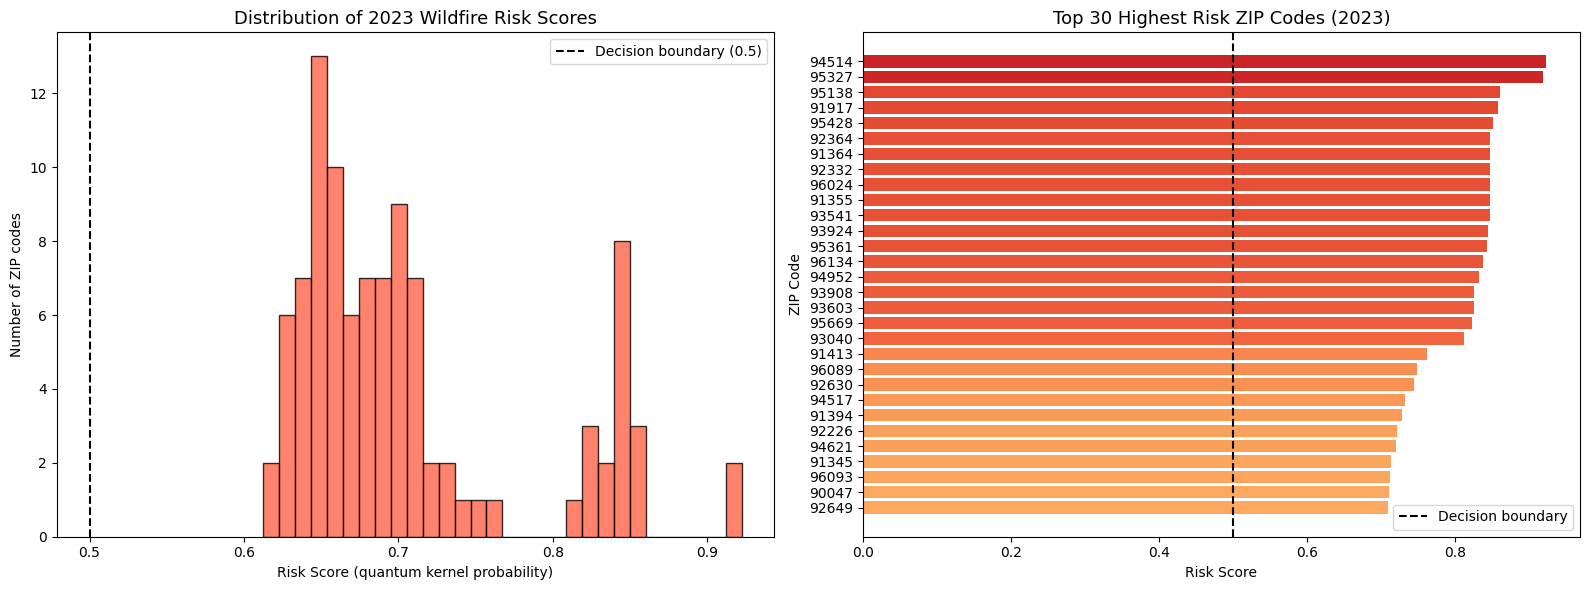

Saved to wildfire_risk_2023.png


In [17]:
# Sort ZIPs by risk score for visualization
results_sorted = results_2023.sort_values("risk_score", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — Risk score distribution
axes[0].hist(results_2023["risk_score"], bins=30, color="tomato", edgecolor="black", alpha=0.8)
axes[0].axvline(x=0.5, color="black", linestyle="--", label="Decision boundary (0.5)")
axes[0].set_title("Distribution of 2023 Wildfire Risk Scores", fontsize=13)
axes[0].set_xlabel("Risk Score (quantum kernel probability)")
axes[0].set_ylabel("Number of ZIP codes")
axes[0].legend()

# Plot 2 — Top 30 highest risk ZIPs
top30 = results_sorted.head(30)
colors = cm.RdYlGn_r(top30["risk_score"].values)
bars = axes[1].barh(top30["zip"].astype(str), top30["risk_score"], color=colors)
axes[1].axvline(x=0.5, color="black", linestyle="--", label="Decision boundary")
axes[1].set_title("Top 30 Highest Risk ZIP Codes (2023)", fontsize=13)
axes[1].set_xlabel("Risk Score")
axes[1].set_ylabel("ZIP Code")
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.savefig("wildfire_risk_2023.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to wildfire_risk_2023.png")